In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

python -m ipykernel install --user --name=ml-env --display-name "Python 3.11 (ML)"



In [2]:
import kagglehub
import glob
import os

# Download dataset
path = kagglehub.dataset_download(
    "rhythmghai/300k-student-performance-prediction-dataset"
)

print("Dataset downloaded to:")
print(path)

# Find CSV files
csv_files = glob.glob(os.path.join(path, "*.csv"))

print("\nCSV files found:")
for file in csv_files:
    print(os.path.basename(file))


Using Colab cache for faster access to the '300k-student-performance-prediction-dataset' dataset.
Dataset downloaded to:
/kaggle/input/300k-student-performance-prediction-dataset

CSV files found:
student_performance_prediction_dataset-2.csv


In [3]:
csv_file = "/kaggle/input/300k-student-performance-prediction-dataset/student_performance_prediction_dataset-2.csv"

data = pd.read_csv(csv_file)

print("Dataset shape:", data.shape)

data.head()


Dataset shape: (300000, 25)


,student_id,age,gender,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,...,social_media_hours,family_income,parent_education,internet_access,device_type,school_type,extracurriculars,final_grade,grade_category,pass_fail
0,1,21,Male,1.645404,79.154521,8.230886,96.053840,7.719620,1.871170,1.447894,...,4.018412,Medium,Master,Yes,Mobile,Private,Coding Club,59.248749,D,Pass
1,2,18,Male,4.462126,72.526685,6.139219,53.024821,6.754758,5.630071,1.891288,...,3.268642,Medium,Master,Yes,Laptop,Public,NaN,58.595595,D,Pass
2,3,19,Female,6.220212,98.531716,6.946313,78.775422,10.000000,7.862877,1.774356,...,2.327293,Low,High School,Yes,Tablet,Private,Music,85.855289,A,Pass
3,4,21,Female,1.826644,97.731245,8.297048,76.122618,7.440486,2.316252,1.204271,...,1.163367,Medium,Bachelor,Yes,Laptop,Public,Debate,42.117503,F,Fail
4,5,17,Male,3.789322,78.589107,6.777171,81.305681,9.962609,5.335697,1.399230,...,0.411183,High,High School,Yes,Laptop,Private,Debate,62.870474,C,Pass


In [4]:
data.describe()

,student_id,age,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,notes_quality_score,time_management_score,motivation_level,mental_health_score,screen_time,social_media_hours,final_grade
count,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000
mean,150000.500000,17.999070,4.503062,84.699395,6.991431,69.840184,7.836044,4.017508,1.529057,6.946017,6.464472,6.945851,6.984210,4.018094,2.530258,53.089206
std,86602.684716,1.999235,1.978513,9.419450,1.463070,14.683157,1.732474,1.956444,0.941525,1.885193,1.925801,1.886246,1.471193,1.958596,1.435742,12.225161
min,1.000000,15.000000,0.000000,40.000000,3.000000,20.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,75000.750000,16.000000,3.143566,78.241008,5.992666,59.870863,6.654817,2.655243,0.826462,5.653740,5.138654,5.655885,5.982593,2.650836,1.491633,44.867737
50%,150000.500000,18.000000,4.498272,84.990371,6.999011,69.955736,8.000829,4.001981,1.499206,7.011212,6.493222,7.005390,6.992543,3.997134,2.498493,53.167495
75%,225000.250000,20.000000,5.843646,91.732244,8.013284,80.102857,9.357154,5.349494,2.172680,8.356150,7.845919,8.356416,8.010331,5.350158,3.513496,61.379373
max,300000.000000,21.000000,12.000000,100.000000,10.000000,100.000000,10.000000,10.000000,5.840593,10.000000,10.000000,10.000000,10.000000,12.000000,8.000000,100.000000


In [5]:
print(data.isnull().sum())
print("Duplicates:", data.duplicated().sum())

student_id                   0
age                          0
gender                       0
study_hours                  0
attendance                   0
sleep_hours                  0
previous_grade               0
assignments_completed        0
practice_tests_taken         0
group_study_hours            0
notes_quality_score          0
time_management_score        0
motivation_level             0
mental_health_score          0
screen_time                  0
social_media_hours           0
family_income                0
parent_education             0
internet_access              0
device_type              15105
school_type                  0
extracurriculars         49981
final_grade                  0
grade_category               4
pass_fail                    0
dtype: int64
Duplicates: 0


In [6]:
data['extracurriculars'] = data['extracurriculars'].fillna('None')
data['device_type'] = data['device_type'].fillna(data['device_type'].mode()[0])

In [7]:
X = data.drop(columns=['student_id', 'final_grade', 'grade_category', 'pass_fail'])
y = data['final_grade']

X = pd.get_dummies(X, drop_first=True)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Model 1: ReLU + Adam (50 Epochs)

In [9]:
model1 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

model1.compile(optimizer='adam', loss='mse', metrics=['mae'])
history1 = model1.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=256)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 329.9126 - mae: 10.9042 - val_loss: 35.7764 - val_mae: 4.7745
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 32.0662 - mae: 4.5157 - val_loss: 30.6152 - val_mae: 4.4147
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 29.1910 - mae: 4.3098 - val_loss: 29.1103 - val_mae: 4.3043
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 28.2071 - mae: 4.2368 - val_loss: 28.5791 - val_mae: 4.2657
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 27.7120 - mae: 4.1986 - val_loss: 28.1794 - val_mae: 4.2314
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 27.3719 - mae: 4.1741 - val_loss: 27.7466 - val_mae: 4.2005
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 27.1184 - mae: 4.1544 - val_loss: 27.6379 - val_mae: 4.1907
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 26.8810 - mae: 4.1359 - val_loss: 27.3547 - val_mae: 4.1697
Epoch 9/50
750/750 ━━━━━━━━━━━━━━━━━━━

In [10]:
model2 = Sequential([
    Dense(64, activation='tanh', input_shape=(X_train.shape[1],)),
    Dense(32, activation='tanh'),
    Dense(1)
])

model2.compile(optimizer='sgd', loss='mse', metrics=['mae'])
history2 = model2.fit(X_train, y_train, validation_split=0.25, epochs=50, batch_size=256)

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 40.5075 - mae: 4.4648 - val_loss: 31.3847 - val_mae: 4.4839
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 25.8234 - mae: 4.0560 - val_loss: 29.5258 - val_mae: 4.3511
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 25.5422 - mae: 4.0337 - val_loss: 26.2246 - val_mae: 4.0899
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 25.3974 - mae: 4.0218 - val_loss: 26.9969 - val_mae: 4.1488
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 25.3330 - mae: 4.0162 - val_loss: 27.5479 - val_mae: 4.1959
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 25.2669 - mae: 4.0093 - val_loss: 26.2658 - val_mae: 4.0936
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 25.2015 - mae: 4.0059 - val_loss: 25.9475 - val_mae: 4.0683
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 25.1695 - mae: 4.0032 - val_loss: 25.9974 - val_mae: 4.0739
Epoch 9/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

In [11]:
model3 = Sequential([
    Dense(64, activation='sigmoid', input_shape=(X_train.shape[1],)),
    Dense(32, activation='sigmoid'),
    Dense(1)
])

model3.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
history3 = model3.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=256)

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1702.3481 - mae: 38.8161 - val_loss: 843.0892 - val_mae: 26.4878
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 399.3419 - mae: 16.5043 - val_loss: 145.2838 - val_mae: 9.5624
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 59.7197 - mae: 5.7495 - val_loss: 28.0139 - val_mae: 4.1777
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 26.1152 - mae: 4.0624 - val_loss: 25.7271 - val_mae: 4.0406
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 25.3070 - mae: 4.0098 - val_loss: 25.4685 - val_mae: 4.0249
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 25.1446 - mae: 3.9996 - val_loss: 25.3785 - val_mae: 4.0184
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 25.0800 - mae: 3.9950 - val_loss: 25.3388 - val_mae: 4.0160
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 25.0519 - mae: 3.9929 - val_loss: 25.3344 - val_mae: 4.0163
Epoch 9/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 

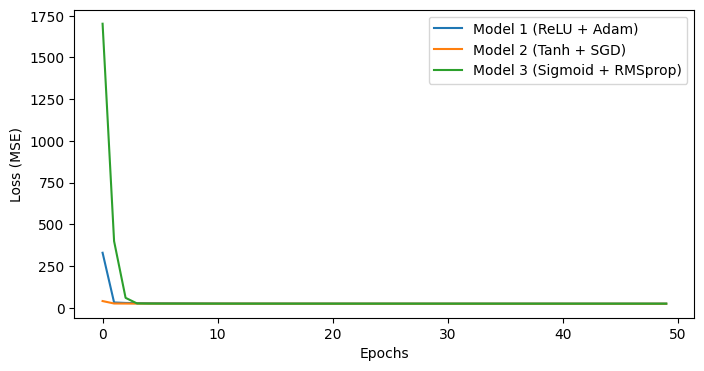

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(history1.history['loss'], label='Model 1 (ReLU + Adam)')
plt.plot(history2.history['loss'], label='Model 2 (Tanh + SGD)')
plt.plot(history3.history['loss'], label='Model 3 (Sigmoid + RMSprop)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [13]:
loss1, mae1 = model1.evaluate(X_test, y_test, verbose=0)
loss2, mae2 = model2.evaluate(X_test, y_test, verbose=0)
loss3, mae3 = model3.evaluate(X_test, y_test, verbose=0)

pred1 = model1.predict(X_test, verbose=0)
pred2 = model2.predict(X_test, verbose=0)
pred3 = model3.predict(X_test, verbose=0)

r2_1 = r2_score(y_test, pred1)
r2_2 = r2_score(y_test, pred2)
r2_3 = r2_score(y_test, pred3)

results = pd.DataFrame({
    'Model': ['Model 1', 'Model 2', 'Model 3'],
    'Activation': ['ReLU', 'Tanh', 'Sigmoid'],
    'Optimizer': ['Adam', 'SGD', 'RMSprop'],
    'Epochs': [50, 50, 50],
    'Loss (MSE)': [loss1, loss2, loss3],
    'MAE': [mae1, mae2, mae3],
    'R2 Score': [r2_1, r2_2, r2_3]
})

results

,Model,Activation,Optimizer,Epochs,Loss (MSE),MAE,R2 Score
0,Model 1,ReLU,Adam,50,25.873230,4.060862,0.825799
1,Model 2,Tanh,SGD,50,26.711483,4.126124,0.820156
2,Model 3,Sigmoid,RMSprop,50,25.252298,4.012469,0.829980


In [14]:
predictions = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': pred1.flatten()[:10]
})
predictions

,Actual,Predicted
0,71.326607,67.101982
1,74.775774,67.197876
2,66.361362,66.913010
3,71.182141,70.027283
4,60.550851,56.980927
5,44.119818,45.705048
6,51.569524,57.281425
7,59.987718,54.607384
8,63.416381,64.273071
9,68.868046,69.685516


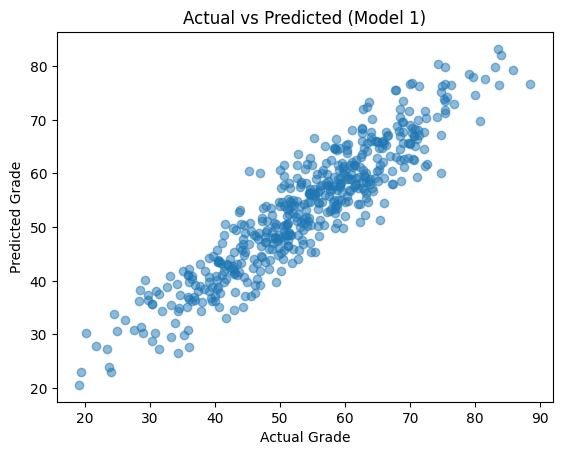

In [15]:
plt.scatter(y_test[:500], pred1[:500], alpha=0.5)
plt.xlabel('Actual Grade')
plt.ylabel('Predicted Grade')
plt.title('Actual vs Predicted (Model 1)')
plt.show()